## Check PSTH layer availability

Loads `data/allen_visual_neuropixels_passive/visp_psths.pkl` and inspects
which layers are available under the `filtered` and `unfiltered` keys,
then plots the mean ± SEM PSTH for each layer so you can verify coverage
before running the optimisation notebook.

In [ ]:
import pickle
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

plt.style.use(Path('..') / 'configs' / 'mpl.mplstyle')

In [2]:
PSTH_PATH = Path('../data/allen_visual_neuropixels_passive/visp_psths.pkl')

with open(PSTH_PATH, 'rb') as f:
    data = pickle.load(f)

meta = data['meta']
t_ms    = meta['time_ms']
bin_ms  = meta['bin_size_ms']

print('Top-level keys:', list(data.keys()))
print()
print('Meta:')
for k, v in meta.items():
    if not isinstance(v, np.ndarray):
        print(f'  {k}: {v}')
print()
for split in ['filtered', 'unfiltered']:
    if split in data:
        layers = sorted(data[split].keys())
        print(f'{split} layers ({len(layers)}): {layers}')
        for lyr in layers:
            e = data[split][lyr]
            print(f'  {lyr:<12}  n_sessions={e["n_sessions"]:>3}  '
                  f'n_units={e["n_units_total"]:>5}  '
                  f'peak_hz={e["mean_hz"].max():>6.2f}')

Top-level keys: ['meta', 'filtered', 'unfiltered']

Meta:
  bin_size_ms: 10.0
  T_PRE_ms: 50.0
  T_POST_ms: 350.0
  P_RF_THRESHOLD: 0.01
  layer_order: ['VISp1', 'VISp2/3', 'VISp2/3a', 'VISp2/3b', 'VISp4', 'VISp5', 'VISp6a', 'VISp6b']
  n_sessions_total: 32
  stim_onset_ms: 0.0
  stim_offset_ms: 250.0

filtered layers (11): ['SSp-bfd2/3', 'SSp-bfd4', 'SSp-bfd5', 'SSp-bfd6a', 'VISp2/3', 'VISp4', 'VISp5', 'VISp6a', 'VISp6b', 'all', 'unknown']
  SSp-bfd2/3    n_sessions=  1  n_units=    1  peak_hz=  4.32
  SSp-bfd4      n_sessions=  1  n_units=    5  peak_hz= 12.80
  SSp-bfd5      n_sessions=  1  n_units=    8  peak_hz= 16.14
  SSp-bfd6a     n_sessions=  1  n_units=    6  peak_hz=  5.56
  VISp2/3       n_sessions= 22  n_units=  217  peak_hz=  9.13
  VISp4         n_sessions= 23  n_units=  335  peak_hz= 11.30
  VISp5         n_sessions= 23  n_units=  483  peak_hz= 13.28
  VISp6a        n_sessions= 22  n_units=  168  peak_hz= 10.57
  VISp6b        n_sessions=  2  n_units=    4  peak_hz= 15.

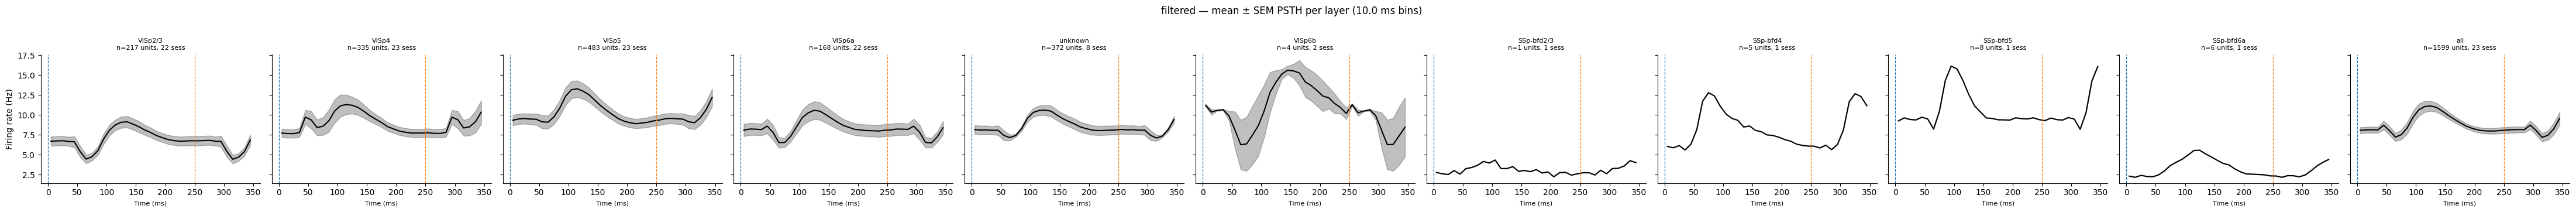

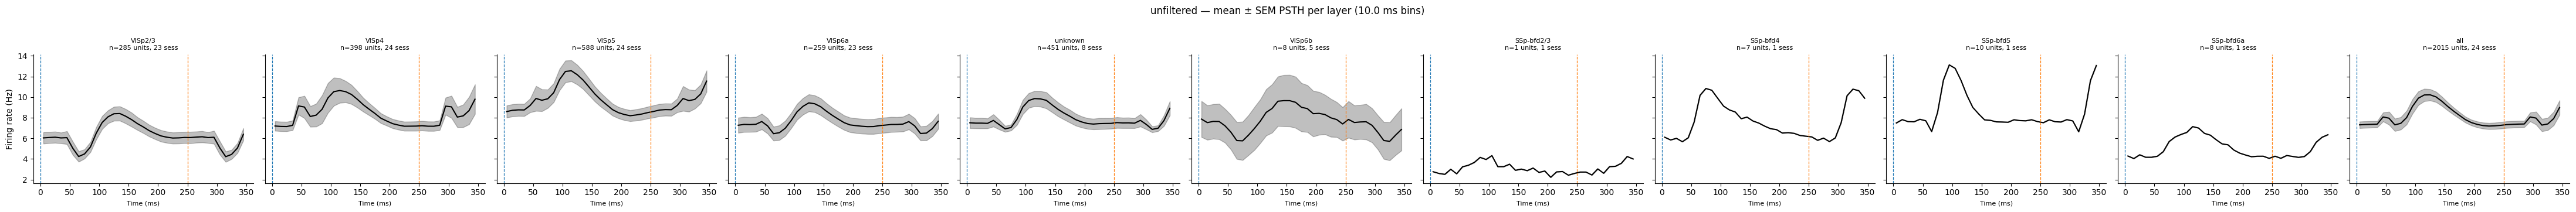

In [4]:
# ── Plot mean ± SEM PSTH per layer for each split ────────────────────────
T_STIM_ONSET_MS  = meta.get('stim_onset_ms',  0.0)
T_STIM_OFFSET_MS = meta.get('stim_offset_ms', 250.0)

for split in ['filtered', 'unfiltered']:
    if split not in data:
        continue
    d = data[split]
    # put 'all' last
    layer_order = [k for k in d if k != 'all'] + (['all'] if 'all' in d else [])
    n = len(layer_order)
    if n == 0:
        continue

    fig, axes = plt.subplots(1, n, figsize=(4 * n, 3.5), sharey=True)
    if n == 1:
        axes = [axes]

    for ax, lyr in zip(axes, layer_order):
        e   = d[lyr]
        hz  = e['mean_hz']
        err = e['sem_hz']
        ax.fill_between(t_ms, hz - err, hz + err, alpha=0.25, color='k')
        ax.plot(t_ms, hz, color='k', lw=1.5)
        ax.axvline(T_STIM_ONSET_MS,  color='tab:blue',   lw=0.9, ls='--')
        ax.axvline(T_STIM_OFFSET_MS, color='tab:orange', lw=0.9, ls='--')
        ax.set_title(
            f"{lyr}\nn={e['n_units_total']} units, {e['n_sessions']} sess",
            fontsize=8
        )
        ax.set_xlabel('Time (ms)', fontsize=8)
        ax.spines[['top', 'right']].set_visible(False)

    axes[0].set_ylabel('Firing rate (Hz)')
    fig.suptitle(
        f'{split} — mean ± SEM PSTH per layer ({bin_ms:.1f} ms bins)',
        y=1.02
    )
    fig.tight_layout()
    # plt.show()
    print()